In [2]:
# Librerías
import pandas as pd
import numpy as np
import datetime

In [3]:
#Leemos el archivo excel

df=pd.read_excel("corregido_open-meteo-37.08N6.42W2m.xlsx", header=0)

print(df)

                     time  temperature_2m (°C)  relative_humidity_2m (%)  \
0     2017-01-01 00:00:00                  6.5                        95   
1     2017-01-01 01:00:00                  5.7                        96   
2     2017-01-01 02:00:00                  5.0                        98   
3     2017-01-01 03:00:00                  4.8                        98   
4     2017-01-01 04:00:00                  4.7                        98   
...                   ...                  ...                       ...   
70123 2024-12-31 19:00:00                  9.4                        77   
70124 2024-12-31 20:00:00                  8.0                        83   
70125 2024-12-31 21:00:00                  7.4                        87   
70126 2024-12-31 22:00:00                  6.6                        88   
70127 2024-12-31 23:00:00                  5.9                        89   

       surface_pressure (hPa)  wind_speed_10m (km/h)  wind_direction_10m (°)  \
0      

In [3]:
df.describe()

,time,temperature_2m (°C),relative_humidity_2m (%),surface_pressure (hPa),wind_speed_10m (km/h),wind_direction_10m (°),wind_speed_100m (km/h),wind_direction_100m (°),wind_gusts_10m (km/h)
count,70128,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000
mean,2020-12-31 23:30:00,18.543586,67.785150,1017.403385,10.258887,191.826474,17.257692,192.485598,21.659895
min,2017-01-01 00:00:00,-1.900000,4.000000,986.200000,0.000000,1.000000,0.000000,1.000000,1.400000
25%,2019-01-01 11:45:00,13.300000,51.000000,1013.700000,6.600000,72.000000,10.900000,77.000000,12.600000
50%,2020-12-31 23:30:00,18.100000,70.000000,1016.500000,9.100000,229.000000,17.100000,227.000000,19.100000
75%,2023-01-01 11:15:00,23.300000,87.000000,1021.000000,13.100000,270.000000,22.500000,268.000000,28.400000
max,2024-12-31 23:00:00,44.400000,100.000000,1038.200000,47.900000,360.000000,76.400000,360.000000,108.400000
std,NaN,7.320375,21.853003,5.726889,5.377497,106.333515,8.594099,103.748582,11.253618


Echando un vistazo al resumen superior vemos que son datos coherentes. 
# Ahora añadimos una nueva columna llamada Incendio y ponemos 1 si hubo y 0 si no hubo.

In [4]:
# Definimos la lista de incendios (Inicio, Fin)

incendios_info = [
    ("2017-06-12 14:00", "2017-06-13 23:59"),
    ("2017-06-24 21:00", "2017-07-04 23:59"),
    ("2019-05-13 14:00", "2019-05-15 23:59"),
    ("2019-06-01 14:00", "2019-06-06 23:59"),
    ("2019-06-07 15:00", "2019-06-07 23:59"),
    ("2019-08-27 10:00", "2019-08-27 23:59"),
    ("2019-09-12 14:00", "2019-09-15 23:59"),
    ("2021-07-24 14:00", "2021-07-28 23:59"),
    ("2021-08-17 14:00", "2021-08-19 23:59"),
    ("2022-07-25 15:00", "2022-07-28 23:59"),
    ("2022-07-25 16:00", "2022-07-28 23:59"), # Nota: Este solapa con el anterior
    ("2023-08-05 14:00", "2023-08-09 23:59")
]

# Inicializamos la columna "incendio" a "no"

df["incendio"] = 0

# Iteramos por cada incendio y marcamos las filas correspondientes
for inicio, fin in incendios_info:
    condicion = (df["time"] >= pd.to_datetime(inicio)) & (df["time"] <= pd.to_datetime(fin))
    df.loc[condicion, "incendio"] = 1

In [5]:
print(df)
# Contamos los missing values
df.isnull().sum()


                     time  temperature_2m (°C)  relative_humidity_2m (%)  \
0     2017-01-01 00:00:00                  6.5                        95   
1     2017-01-01 01:00:00                  5.7                        96   
2     2017-01-01 02:00:00                  5.0                        98   
3     2017-01-01 03:00:00                  4.8                        98   
4     2017-01-01 04:00:00                  4.7                        98   
...                   ...                  ...                       ...   
70123 2024-12-31 19:00:00                  9.4                        77   
70124 2024-12-31 20:00:00                  8.0                        83   
70125 2024-12-31 21:00:00                  7.4                        87   
70126 2024-12-31 22:00:00                  6.6                        88   
70127 2024-12-31 23:00:00                  5.9                        89   

       surface_pressure (hPa)  wind_speed_10m (km/h)  wind_direction_10m (°)  \
0      

time                        0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
surface_pressure (hPa)      0
wind_speed_10m (km/h)       0
wind_direction_10m (°)      0
wind_speed_100m (km/h)      0
wind_direction_100m (°)     0
wind_gusts_10m (km/h)       0
incendio                    0
dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,  ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
#Creamos los vectores X e Y

X= df.drop(columns=["time","incendio"])
Y=df["incendio"]

#Dividimos los datos en conjunto de entrenamiento y prueba

# 3. División en entrenamiento y prueba por fecha
# Definimos la fecha de corte
fecha_corte = pd.to_datetime('2022-07-01')

# Creamos máscaras para no modificar el dataframe original
es_train = pd.to_datetime(df['time']) < fecha_corte
es_test = pd.to_datetime(df['time']) >= fecha_corte

# Creamos X e Y filtrando y soltando columnas solo para el modelo
X_train = df[es_train].drop(columns=['time', 'incendio'])
Y_train = df.loc[es_train, 'incendio']

original_column_names = list(X_train.columns)


X_test = df[es_test].drop(columns=['time', 'incendio'])
Y_test = df.loc[es_test, 'incendio']

Accuracy: 0.7036218451447313

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.70      0.82     13854
           1       0.04      0.90      0.07       172

    accuracy                           0.70     14026
   macro avg       0.52      0.80      0.45     14026
weighted avg       0.99      0.70      0.81     14026



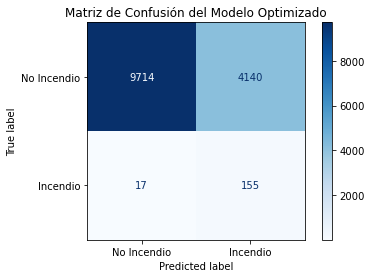

In [9]:
from sklearn.decomposition import PCA


#Ahora estandarizamos el modelo, aplicamos PCA y lo ajustamos usando pipeline

pipe=make_pipeline(StandardScaler(), PCA(n_components=0.95), SVC(
                                                                kernel='rbf',
                                                                class_weight='balanced',
                                                                random_state=42))
pipe.fit(X_train, Y_train)
Y_pred=pipe.predict(X_test)

# Finalmente, evaluamos el modelo

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nReporte de clasificación:")
print(classification_report(Y_test, Y_pred))

# Crear la matriz
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Incendio', 'Incendio'])
# Dibujar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión del Modelo Optimizado")
plt.show()

In [13]:
pca_step = pipe.named_steps['pca']
print(f"Número de componentes elegidos: {pca_step.n_components_}")
print(f"Varianza total explicada: {sum(pca_step.explained_variance_ratio_):.2f}")

Número de componentes elegidos: 5
Varianza total explicada: 0.96


In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    
    'svc__C': [2, 10],
    'svc__gamma': ['auto']
}

grid = GridSearchCV(pipe, param_grid, cv=5, verbose=3)
grid.fit(X_train, Y_train)

print(f"Mejores parámetros: {grid.best_params_}")

y_pred_opt =grid.best_estimator_.predict(X_test)

# Crear la matriz
cm = confusion_matrix(Y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Incendio', 'Incendio'])

# Dibujar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión del Modelo Optimizado")
plt.show()

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END ......svc__C=0.1, svc__gamma=scale;, score=0.661 total time= 1.8min
[CV 2/5] END ......svc__C=0.1, svc__gamma=scale;, score=0.689 total time= 1.7min
[CV 3/5] END ......svc__C=0.1, svc__gamma=scale;, score=0.665 total time= 1.8min
[CV 4/5] END ......svc__C=0.1, svc__gamma=scale;, score=0.676 total time= 1.8min
[CV 5/5] END ......svc__C=0.1, svc__gamma=scale;, score=0.667 total time= 1.8min
[CV 1/5] END .......svc__C=0.1, svc__gamma=auto;, score=0.679 total time= 1.7min
[CV 2/5] END .......svc__C=0.1, svc__gamma=auto;, score=0.710 total time= 1.6min
[CV 3/5] END .......svc__C=0.1, svc__gamma=auto;, score=0.687 total time= 1.7min
[CV 4/5] END .......svc__C=0.1, svc__gamma=auto;, score=0.692 total time= 1.6min
[CV 5/5] END .......svc__C=0.1, svc__gamma=auto;, score=0.688 total time= 1.7min
[CV 1/5] END .......svc__C=10, svc__gamma=scale;, score=0.734 total time= 1.5min
[CV 2/5] END .......svc__C=10, svc__gamma=scale;,

NameError: name 'y_test' is not defined

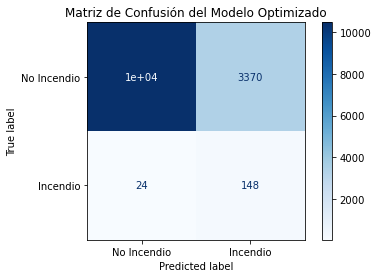

In [23]:
# Crear la matriz
cm = confusion_matrix(Y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Incendio', 'Incendio'])

# Dibujar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión del Modelo Optimizado")
plt.show()

Ahora optimizamos PCA

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV 1/5] END pca__n_components=0.9, svc__C=10, svc__gamma=auto;, score=0.679 total time=  43.0s
[CV 2/5] END pca__n_components=0.9, svc__C=10, svc__gamma=auto;, score=0.703 total time=  42.9s
[CV 3/5] END pca__n_components=0.9, svc__C=10, svc__gamma=auto;, score=0.684 total time=  44.1s
[CV 4/5] END pca__n_components=0.9, svc__C=10, svc__gamma=auto;, score=0.691 total time=  42.9s
[CV 5/5] END pca__n_components=0.9, svc__C=10, svc__gamma=auto;, score=0.695 total time=  48.9s
[CV 1/5] END pca__n_components=0.95, svc__C=10, svc__gamma=auto;, score=0.759 total time=  43.4s
[CV 2/5] END pca__n_components=0.95, svc__C=10, svc__gamma=auto;, score=0.781 total time=  54.0s
[CV 3/5] END pca__n_components=0.95, svc__C=10, svc__gamma=auto;, score=0.761 total time=  39.6s
[CV 4/5] END pca__n_components=0.95, svc__C=10, svc__gamma=auto;, score=0.760 total time=  39.8s
[CV 5/5] END pca__n_components=0.95, svc__C=10, svc__gamma=auto;, score=

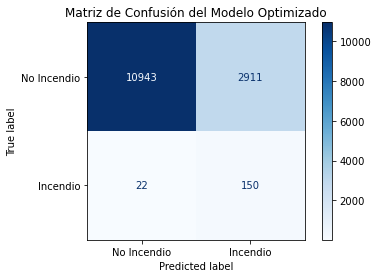

In [12]:
from sklearn.model_selection import GridSearchCV

pipe=make_pipeline(StandardScaler(), PCA(), SVC(
                                                kernel='rbf',
                                                class_weight='balanced',
                                                random_state=42))

param_grid = {
    
    'pca__n_components':[0.9, 0.95,0.97],
    'svc__C': [10],
    'svc__gamma': ['auto']
}

grid = GridSearchCV(pipe, param_grid, cv=5, verbose=3)
grid.fit(X_train, Y_train)

print(f"Mejores parámetros: {grid.best_params_}")

y_pred_opt =grid.best_estimator_.predict(X_test)

# Crear la matriz
cm = confusion_matrix(Y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Incendio', 'Incendio'])

# Dibujar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión del Modelo Optimizado")
plt.show()

In [16]:
pca_step = grid.best_estimator_.named_steps['pca']
print(f"Número de componentes elegidos: {pca_step.n_components_}")
print(f"Varianza total explicada: {sum(pca_step.explained_variance_ratio_):.2f}")

Número de componentes elegidos: 6
Varianza total explicada: 0.98


Fitting 3 folds for each of 54 candidates, totalling 162 fits
Mejores parámetros para recall: {'pca__n_components': 0.9, 'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Mejores parámetros para f1: {'pca__n_components': 0.97, 'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'auto', 'svc__kernel': 'poly'}


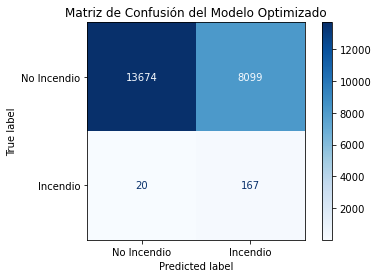

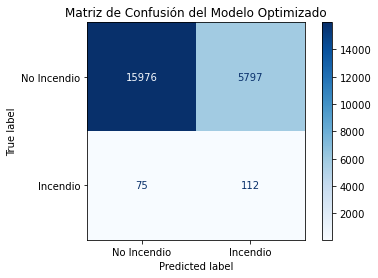

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


pipeline = Pipeline([('scaler', StandardScaler()),
                     ('pca', PCA()),
                     ('svc', SVC())])

param_grid = {
    'pca__n_components':[0.9, 0.95,0.97],
    'svc__C': [1, 5, 10],
    'svc__class_weight': ['balanced'],
    'svc__kernel': ['linear','rbf', 'poly'] ,
    'svc__gamma': ['scale', 'auto']
}

# Para optimizar Recall
grid_recall = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='recall',
    verbose=2,
    n_jobs=-1
)

# Para optimizar F1-score
grid_f1 = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

grid_recall.fit(X_train, Y_train)

print(f"Mejores parámetros para recall: {grid_recall.best_params_}")

grid_f1.fit(X_train, Y_train)

print(f"Mejores parámetros para f1: {grid_f1.best_params_}")

Y_pred_recall =grid_recall.best_estimator_.predict(X_test)

Y_pred_f1 =grid_f1.best_estimator_.predict(X_test)

# Crear la matriz
cm = confusion_matrix(Y_test, Y_pred_recall)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Incendio', 'Incendio'])

# Dibujar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión del Modelo Optimizado")
plt.show()

# Crear la matriz
cm = confusion_matrix(Y_test, Y_pred_f1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Incendio', 'Incendio'])

# Dibujar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión del Modelo Optimizado")
plt.show()

Index([48759, 48760, 48761, 48762, 48763, 48764, 48765, 48766, 48767, 48768,
       48769, 48770, 48771, 48772, 48773, 48774, 48775, 48776, 48777, 48778,
       48779, 48780, 48781, 48782, 48783, 48784, 48785, 48786, 48787, 48788,
       48789, 48790, 48791, 48792, 48793, 48794, 48795, 48796, 48797, 48798,
       48799, 48800, 48801, 48802, 48803, 48804, 48805, 48806, 48807, 48808,
       48809, 48810, 48811, 48812, 48813, 48814, 48815, 48816, 48817, 48818,
       48819, 48820, 48821, 48822, 48823, 48824, 48825, 48826, 48827, 48828,
       48829, 48830, 48831, 48832, 48833, 48834, 48835, 48836, 48837, 48838,
       48839],
      dtype='int64')


C:\Users\silvi\AppData\Local\Temp/ipykernel_7340/2661332576.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_incendio_test['fecha'] = df.loc[df_incendio_test.index, df.columns[0]]


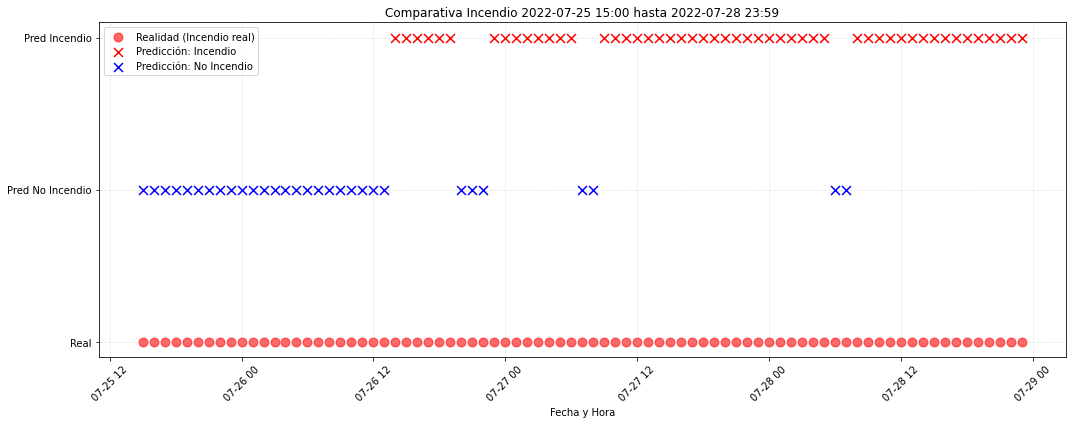

Se han detectado 51 horas del incendio de 81 horas. 


In [10]:
# 1. Buscamos los índices (los números de la izquierda) que corresponden a esas fechas
mask_incendio = (df.iloc[:, 0] >= "2022-07-25 15:00") & (df.iloc[:, 0] <= "2022-07-28 23:59")
indices_incendio = df[mask_incendio].index

print(indices_incendio)
# 2. Creamos un DataFrame de resultados uniendo y_test e y_pred_opt
# Importante: X_test conserva el índice original (ej: 71, 72...)
df_resultados = pd.DataFrame({
    'real': Y_test,
    'prediccion': Y_pred_f1
}, index=Y_test.index)

df_resultados
# 3. Filtramos df_resultados usando solo los índices que encontramos en el paso 1
# Esto selecciona solo las filas del incendio que cayeron en tu set de TEST
df_incendio_test = df_resultados.loc[df_resultados.index.isin(indices_incendio)]

df_incendio_test

# 4. Recuperamos las fechas para el eje X
df_incendio_test['fecha'] = df.loc[df_incendio_test.index, df.columns[0]]
df_incendio_test = df_incendio_test.sort_values('fecha')
 
df_incendio_test
# --- Visualización ---
plt.figure(figsize=(15, 6))

# --- REALIDAD: siempre abajo en rojo ---
plt.scatter(
    df_incendio_test['fecha'], 
    [0]*len(df_incendio_test),   # todos abajo
    color='red', 
    label='Realidad (Incendio real)', 
    s=80, 
    alpha=0.6
)

# --- PREDICCIONES ---
# Predicción = 1 (Incendio) -> cruces rojas arriba
pred_si = df_incendio_test[df_incendio_test['prediccion'] == 1]
plt.scatter(
    pred_si['fecha'], 
    [1]*len(pred_si), 
    color='red', 
    marker='x', 
    label='Predicción: Incendio', 
    s=80
)

# Predicción = 0 (No incendio) -> cruces azules a otra altura
pred_no = df_incendio_test[df_incendio_test['prediccion'] == 0]
plt.scatter(
    pred_no['fecha'], 
    [0.5]*len(pred_no),  # altura intermedia
    color='blue', 
    marker='x', 
    label='Predicción: No Incendio', 
    s=80
)

# Ejes y estilo
plt.yticks([0, 0.5, 1], ['Real', 'Pred No Incendio', 'Pred Incendio'])
plt.title('Comparativa Incendio 2022-07-25 15:00 hasta 2022-07-28 23:59')
plt.xlabel('Fecha y Hora')
plt.grid(True, axis='both', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Finalmente, contamos cuantas horas de incendio predice bien

total_incendios_predichos = df_incendio_test['prediccion'].sum()

print(f'Se han detectado {total_incendios_predichos} horas del incendio de {len(df_incendio_test)} horas. ' )

In [11]:
from sklearn.inspection import permutation_importance

X_test_df = pd.DataFrame(X_test, columns=original_column_names)

result = permutation_importance(
    grid_f1.best_estimator_,
    X_test_df,
    Y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importancia = pd.DataFrame({
    'Variable': original_column_names,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=False)

print(importancia)

                   Variable  Importancia
0       temperature_2m (°C)     0.112404
1  relative_humidity_2m (%)     0.106840
5    wind_speed_100m (km/h)     0.045510
2    surface_pressure (hPa)     0.030246
7     wind_gusts_10m (km/h)     0.000036
4    wind_direction_10m (°)    -0.003087
3     wind_speed_10m (km/h)    -0.005164
6   wind_direction_100m (°)    -0.012432


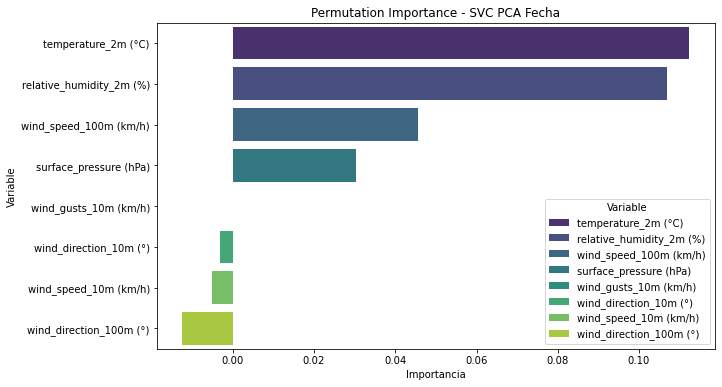

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variable', data=importancia, hue='Variable',
    dodge=False,
    palette='viridis')
plt.title("Permutation Importance - SVC PCA Fecha")
plt.show()

In [15]:
import joblib

joblib.dump(grid_f1.best_estimator_, 'modelo_svc_pca_fecha.pkl')

['modelo_svc_pca_fecha.pkl']